¡Hola Catalina! Espero estés bien.

Mi nombre es **Gina Buvoli**. Un gusto conocerte, seré tu revisora en este proyecto.

A continuación, te comparto un poco sobre la modalidad de revisión que vamos a usar:

Cuando encuentre un error por primera vez, simplemente lo señalaré y dejaré que lo detectes y corrijas por tu cuenta. Además, a lo largo del proyecto iré haciendo algunas observaciones para mejorar tu código, así como comentarios sobre tus conclusiones o percepciones sobre el tema.

Si en algún momento no logras resolver la tarea, en la siguiente iteración te daré una pista más precisa, junto con algunos ejemplos prácticos. También estoy abierta a responder cualquier duda que tengas.

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:

<div class="alert alert-block alert-success">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Éxito ✅</b><br>
¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis. Continúa aplicando estas buenas prácticas en futuras secciones.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>Atención ⚠️</b><br>
El código es correcto, pero hay una recomendación de mejora. No bloquea la aprobación, pero vale la pena ajustarlo.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario de la revisora [#° iteración]</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
Aquí hay un error que es necesario corregir para aprobar. Por favor revisa este punto antes de volver a enviar.
</div>

---

En cada revisión recibirás un **Comentario General** que resume los aspectos positivos, las áreas de mejora y los próximos pasos.

También puedes responderme copiando el siguiente bloque si tienes alguna duda:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante [#° iteración]</b> <a class="tocSkip"></a>

Aquí puedes escribir tu respuesta o pregunta.
</div>

**¡Empecemos!** 🚀


<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

¡Hola Catalina!

Tu proyecto está bien encaminado: cargas y preparas correctamente el dataset, calculas las ventas totales, construyes análisis por plataforma, género y región, y tus visualizaciones ayudan a seguir el razonamiento. También se nota una intención clara de justificar decisiones, por ejemplo al trabajar con los últimos 10 años para el análisis de plataformas.

Sin embargo, el proyecto necesita una corrección bloqueante antes de aprobar:

1. En las pruebas de hipótesis estás usando <code>alpha = 0.5</code>. Este valor no es adecuado para este proyecto porque implica aceptar un margen de error del 50%. Debes usar el nivel estándar <code>alpha = 0.05</code> y reinterpretar los resultados, especialmente la prueba entre los géneros Action y Sports.

Cuando ajustes ese punto, revisa también la conclusión final para que quede alineada con el nuevo criterio estadístico.


</div>


<div class="alert alert-block alert-success">
<b>Review General. (Iteración 2)</b> <a class="tocSkip"></a>

¡Hola Catalina!

Gracias por realizar la corrección solicitada. Revisé el punto rojo de la iteración anterior y ahora las pruebas de hipótesis usan correctamente <code>alpha = 0.05</code>. Además, la interpretación quedó alineada con los resultados: se rechaza H₀ para la comparación entre XOne y PC, y no se rechaza H₀ para Action vs Sports.

Con esta corrección, el proyecto queda aprobado. Muy buen trabajo ajustando el criterio estadístico y manteniendo una lectura clara de los resultados.

Saludos,  
Gina Buvoli
</div>

# Paso 1. Importar librerías

In [1]:
import pandas as pd
from scipy import stats as st
import math as mt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

# Paso 2. Importar archivo de datos

In [2]:
games = pd.read_csv('/datasets/games.csv', sep= ',')
print(games.head())
print(games.info())

                       Name Platform  Year_of_Release         Genre  NA_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   EU_sales  JP_sales  Other_sales  Critic_Score User_Score Rating  
0     28.96      3.77         8.45          76.0          8      E  
1      3.58      6.81         0.77           NaN        NaN    NaN  
2     12.76      3.79         3.29          82.0        8.3      E  
3     10.93      3.28         2.95          80.0          8      E  
4      8.89     10.22         1.00           NaN        NaN    NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Buen inicio, Catalina. Cargas correctamente el archivo <code>games.csv</code> y haces una exploración inicial con <code>head()</code> e <code>info()</code>, lo cual permite revisar estructura, tipos de datos y valores ausentes antes de transformar el dataset.
</div>


# Paso 3. Preparar los datos

Ahora se hará el reemplazo de los nombres de las columnas a minúsculas y cambiar el tipo de dato de 'year_of_release' de float a int. Por ahora, se van a mantener los valores ausentes como ausentes (NaN), ya que la idea es mantener los datos inalterados, para que el análisis posterior sea correcto.

In [3]:
### Cambio de nombres de columnas
games.columns = games.columns.str.lower()

print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


Ahora se hará el cambio de tipo de dato de 'user_score' de object a float y también se van a cambiar los valores tbd por NaN para poder manejar los valores como float y no como object. Esto ya que como aún no están definidos esos valores, es similar a tener un valor ausente y así también se mantienen los datos íntegros para el análisis posterior.

In [4]:
## Cambio de tipo de dato de 'user_score'
games['user_score'] = (games['user_score'].replace('tbd', np.nan).astype(float))

print(games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  
0     28.96      3.77         8.45          76.0         8.0      E  
1      3.58      6.81         0.77           NaN         NaN    NaN  
2     12.76      3.79         3.29          82.0         8.3      E  
3     10.93      3.28         2.95          80.0         8.0      E  
4      8.89     10.22         1.00           NaN         NaN    NaN  


## Revisar ahora porqué hay valores ausentes:

In [5]:
games[games.isna().any(axis=1)].sort_values(by='year_of_release', ascending=True)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
6875,Checkers,2600,1980.0,Misc,0.22,0.01,0.0,0.00,NaN,NaN,NaN
546,Missile Command,2600,1980.0,Shooter,2.56,0.17,0.0,0.03,NaN,NaN,NaN
4019,Ice Hockey,2600,1980.0,Sports,0.46,0.03,0.0,0.01,NaN,NaN,NaN
6300,Bridge,2600,1980.0,Misc,0.25,0.02,0.0,0.00,NaN,NaN,NaN
262,Asteroids,2600,1980.0,Shooter,4.00,0.26,0.0,0.05,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.0,0.00,43.0,NaN,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.0,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.0,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.0,0.00,NaN,NaN,NaN


Se puede ver que la mayoría de los casos donde hay valores ausentes esto se repite tanto para critic_score, user_score y rating. Esto puede deberse en parte al año de lanzamiento del juego, donde quizás la modalidad de hacer reseñas de los juegos en ese tiempo no existía y no hay una base de datos fidedigna de las puntuaciones que le han dado a los juegos. Por otro lado, también puede ser que estos mismos juegos que no tienen critic y user_score no tengan rating, ya que quizás, para poder obtener un rating certero, se necesita quizás alguna puntuación (especulativo).

## Evaluar la tabla rating para entender qué significan las siglas.

In [6]:
sorted(games['rating'].dropna().unique())

['AO', 'E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T']

Efectivamente las siglas que aparecen son las utilizadas por el ESRB que significan lo siguiente:
E → Everyone
E10+ → Everyone 10+
T → Teen
M → Mature
AO → Adults Only
EC → Early Childhood
K-A -> Kids to Adults (antigua clasificación para E)
RP -> Rating Pending (Clasificación pendiente).
Ya que K-A y E significan lo mismo, se van a cambiar los valores de K-A por E para que en los análisis entreguen la misma información y no se interpreten como dos clasificaciones diferentes.

In [7]:
## Cambiar los valores 'K-A' por 'E' en la columna 'rating'
games['rating'] = games['rating'].replace('K-A', 'E')
sorted(games['rating'].dropna().unique())

['AO', 'E', 'E10+', 'EC', 'M', 'RP', 'T']

## Cálculo de ventas totales para cada juego

In [8]:
## Suma de eu_sales, jp_sales, na_sales y other_sales en nueva columna 'total_sales'
games['total_sales'] = games['eu_sales'] + games['na_sales'] + games['jp_sales'] + games['other_sales']
print(games.head())

                       name platform  year_of_release         genre  na_sales  \
0                Wii Sports      Wii           2006.0        Sports     41.36   
1         Super Mario Bros.      NES           1985.0      Platform     29.08   
2            Mario Kart Wii      Wii           2008.0        Racing     15.68   
3         Wii Sports Resort      Wii           2009.0        Sports     15.61   
4  Pokemon Red/Pokemon Blue       GB           1996.0  Role-Playing     11.27   

   eu_sales  jp_sales  other_sales  critic_score  user_score rating  \
0     28.96      3.77         8.45          76.0         8.0      E   
1      3.58      6.81         0.77           NaN         NaN    NaN   
2     12.76      3.79         3.29          82.0         8.3      E   
3     10.93      3.28         2.95          80.0         8.0      E   
4      8.89     10.22         1.00           NaN         NaN    NaN   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
La preparación de datos está bien resuelta. Convertiste los nombres de columnas a minúsculas, reemplazaste <code>'tbd'</code> por valores ausentes antes de transformar <code>user_score</code> a numérico, y calculaste correctamente <code>total_sales</code> sumando las ventas regionales.
</div>


# Paso 4. Análisis de datos

### Gráfico de barras para determinar cuántos juegos se lanzaron por año

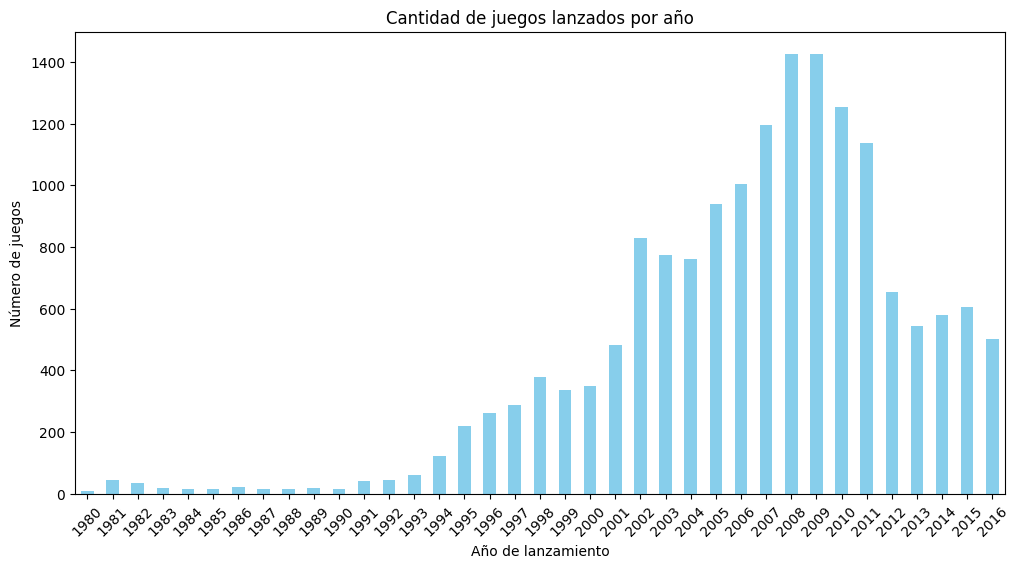

In [9]:
## Graficar cantidad de juegos en función de los años


# Conteo de juegos por año ignorando los NaN
games_per_year = games['year_of_release'].dropna().value_counts().sort_index()

# Crear gráfico
plt.figure(figsize=(12,6))
ax = games_per_year.plot(kind='bar', color='skyblue')

# Títulos y etiquetas
plt.title('Cantidad de juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')

# Formatear etiquetas del eje X para que no tengan decimales
ax.set_xticklabels([str(int(x)) for x in games_per_year.index], rotation=45)

# Mostrar gráfico
plt.show()



#### ¿Cómo se observa la cantidad de juegos lanzados por año?
Se observa un crecimiento acelerado de lanzamiento de juegos entre el año 2001 al 2009, con su peak en los años 2008 y 2009. Desde el año 2012 al 2016 ha sido más estable en alrededor de 400 al 600 juegos lanzados. Entre los años 1980 a 1993, se lanzaban muy pocos juegos (menos de 100 al año).

## Ventas de juegos por plataforma 

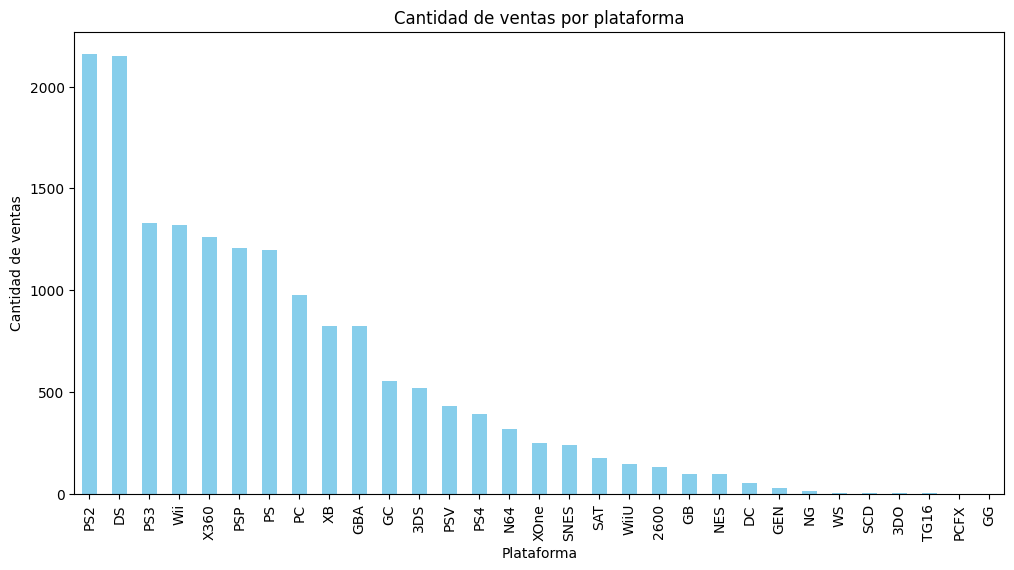

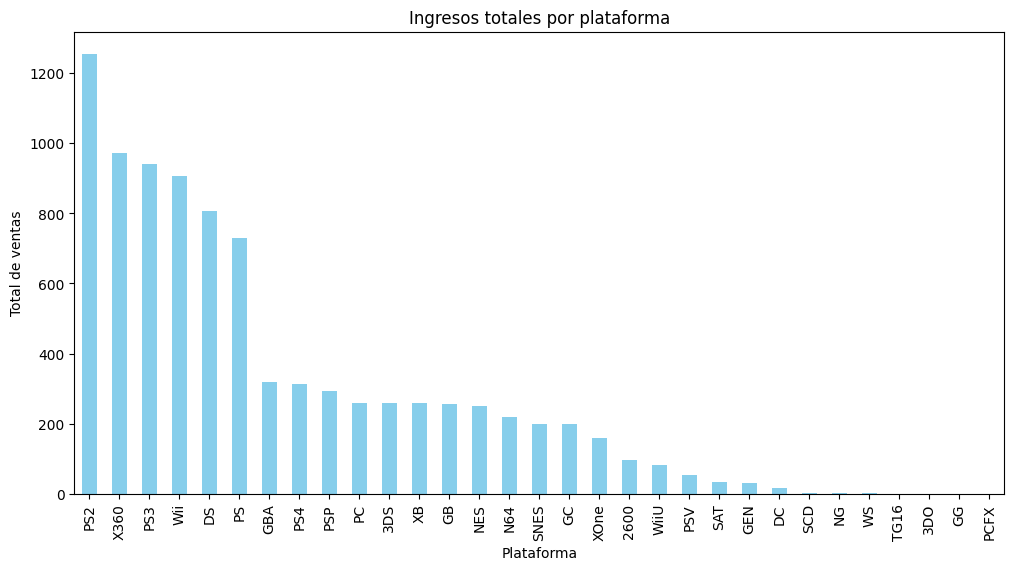

In [10]:
## Determinar cuáles son las plataformas y verificar si alguna se repite
sorted(games['platform'].dropna().unique())


## Graficar plataformas de venta vs. cantidad de ventas
# Conteo de ventas por plataforma ignorando los NaN
ventas_por_plataforma = games['platform'].dropna().value_counts().sort_values(ascending=False)

# Crear gráfico
plt.figure(figsize=(12,6))
ventas_por_plataforma.plot(kind='bar', color='skyblue')

# Títulos y etiquetas
plt.title('Cantidad de ventas por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Cantidad de ventas')

# Mostrar gráfico
plt.show()

## Graficar plataformas de venta vs. total de ventas (en M$US)

# Total de ingresos por ventas por plataforma ignorando los NaN
ingresos_por_plataforma = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

# Crear gráfico
plt.figure(figsize=(12,6))
ingresos_por_plataforma.plot(kind='bar', color='skyblue')

# Títulos y etiquetas
plt.title('Ingresos totales por plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Total de ventas')

# Mostrar gráfico
plt.show()



#### Se va a trabajar con las plataformas que tengan más de 300 ventas y, además, que sus ingresos totales sean mayores a los 250 mill. de dólares. Luego, se va a determinar las ventas por año de estas plataformas. 

In [11]:
### Filtrar por plataformas con >500 ventas e ingresos >200 mill. dólares
# 1. Ventas totales por plataforma
ventas_por_plataforma = games.groupby('platform')['total_sales'].sum()

# 2. Cantidad de juegos por plataforma
juegos_por_plataforma = games.groupby('platform').size()

# 3. Filtros
filtro_ingresos = ventas_por_plataforma > 250
filtro_juegos = juegos_por_plataforma > 300

# 4. Unir ambos criterios
plataformas_top = ventas_por_plataforma[filtro_ingresos & filtro_juegos].index
print(plataformas_top)

# 5. Nuevo DF solo con esas plataformas
games_filtrado = games[games['platform'].isin(plataformas_top)]
print(games_filtrado)


Index(['3DS', 'DS', 'GBA', 'PC', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'Wii',
       'X360', 'XB'],
      dtype='object', name='platform')
                                                   name platform  \
0                                            Wii Sports      Wii   
2                                        Mario Kart Wii      Wii   
3                                     Wii Sports Resort      Wii   
6                                 New Super Mario Bros.       DS   
7                                              Wii Play      Wii   
...                                                 ...      ...   
16708                Woody Woodpecker in Crazy Castle 5      GBA   
16709  SCORE International Baja 1000: The Official Game      PS2   
16710                     Samurai Warriors: Sanada Maru      PS3   
16711                                  LMA Manager 2007     X360   
16713                                  Spirits & Spells      GBA   

       year_of_release     genre  na_sales  eu_s

<Figure size 1400x700 with 0 Axes>

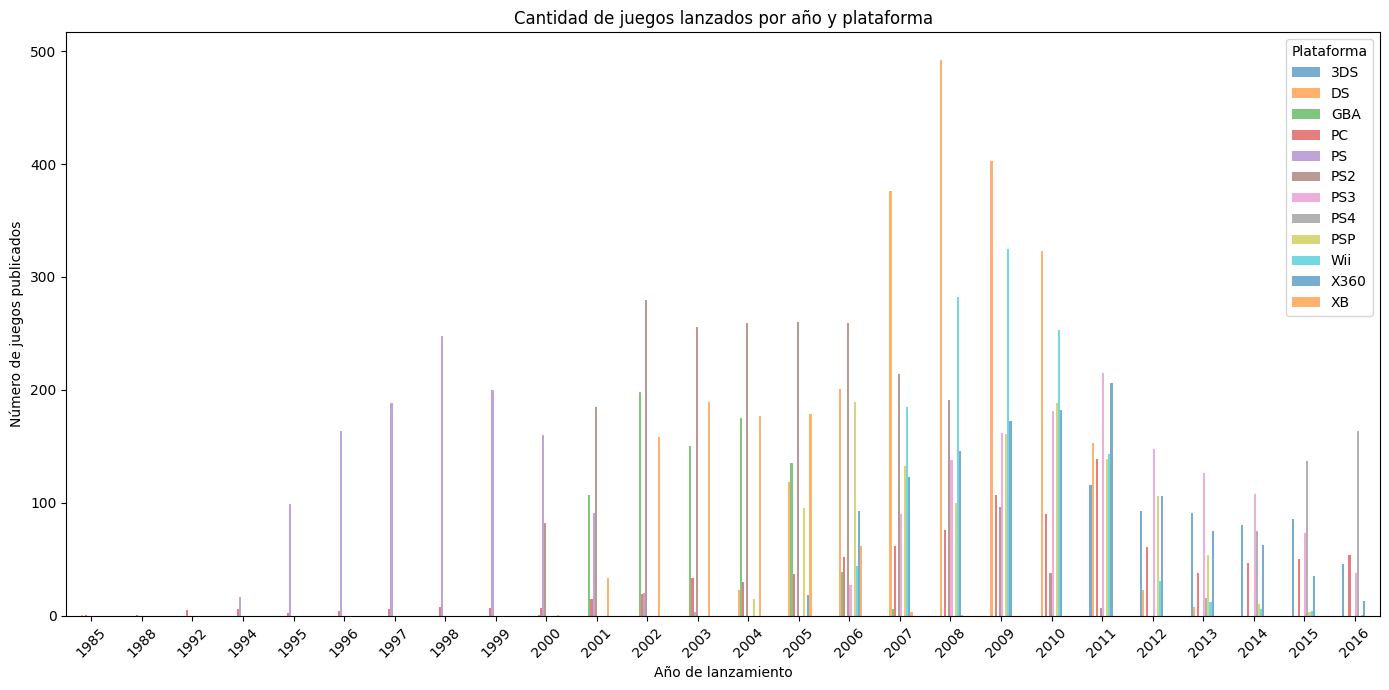

In [12]:
## Crear una tabla con year_of_release y platform
tabla_year_platform = (
    games_filtrado
    .dropna(subset=['year_of_release'])
    .groupby(['year_of_release', 'platform'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

plt.figure(figsize=(14,7))

tabla_year_platform.plot(kind='bar', figsize=(14,7), alpha=0.6)

plt.title('Cantidad de juegos lanzados por año y plataforma')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos publicados')

# Formatear etiquetas del eje X sin decimales
plt.xticks(
    ticks=range(len(tabla_year_platform.index)),
    labels=[str(int(x)) for x in tabla_year_platform.index],
    rotation=45
)

plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

<Figure size 1400x700 with 0 Axes>

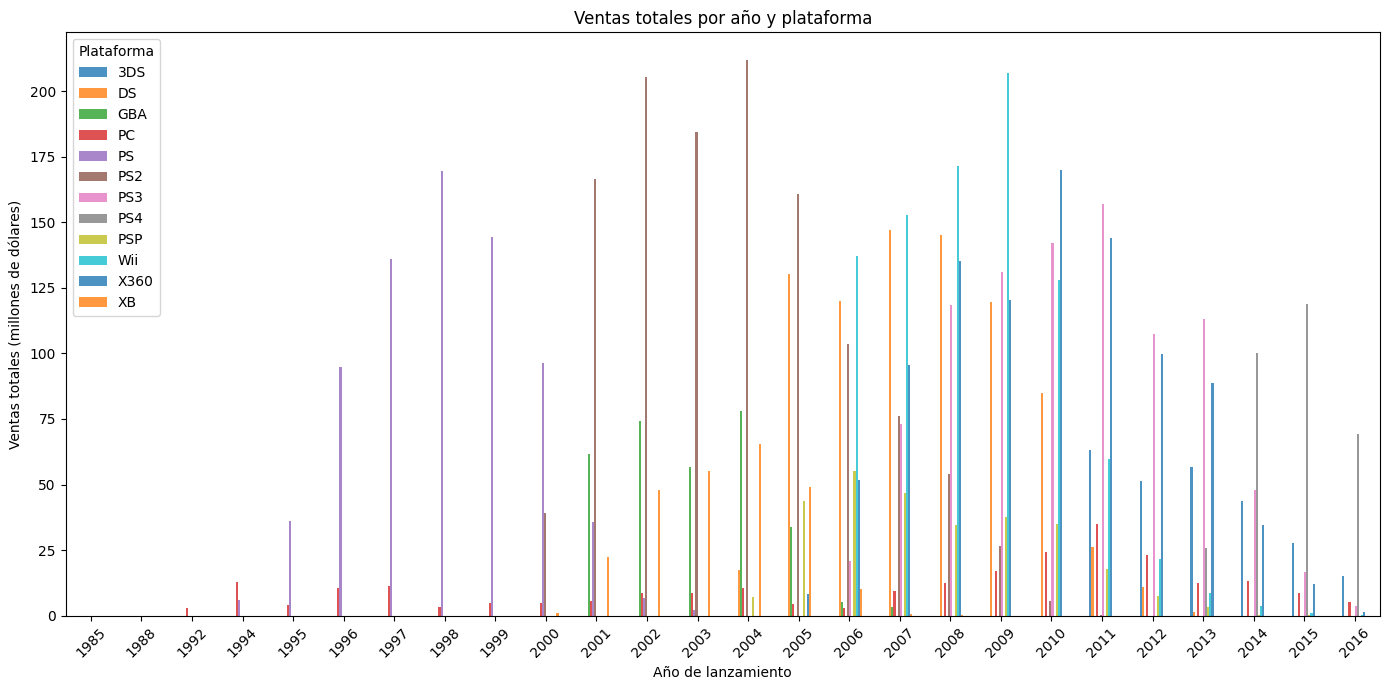

In [13]:
## Crear tabla de plataformas y cantidad de ventas
tabla_ventas = (
    games_filtrado
    .dropna(subset=['year_of_release'])
    .groupby(['year_of_release', 'platform'])['total_sales']
    .sum()
    .unstack(fill_value=0)
    .sort_index()
)

## Crear gráfico
plt.figure(figsize=(14,7))

# Gráfico de líneas
tabla_ventas.plot(kind='bar', figsize=(14,7), alpha=0.8)

plt.title('Ventas totales por año y plataforma')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (millones de dólares)')

# Formatear eje X sin decimales
plt.xticks(
    ticks=range(len(tabla_ventas.index)),
    labels=[str(int(x)) for x in tabla_ventas.index],
    rotation=45
)

plt.legend(title='Plataforma')
plt.tight_layout()
plt.show()

#### ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?
Las plataformas antiguas como el PC, aún existen para vender juegos a pesar de que sus ventan no se acequen a otras plataformas, pero es constante.También el PlayStation 1 y 2 demoraron 11 años en desaparecer del mercado y la GBA y la XB entre 6 a 5 años en culminar sus ventas.
En cuanto a las plataformas más nuevas, la Wii duró 7 años, la PS3 duró 11 años y la PS4 lleva ya 3 años (2013 hasta al menos el 2016). Por tanto, la antiguedad de las plataformas no habla mucho sobre la durabilidad de estas en el mercado, pero si genera curiosidad de que la GBA, XB y Wii no duraran tanto como el resto. Problemente viene marcado por el lanzamiento de nuevas plataformas como la PS3 y PS4 que generó en el 2006, una caída para la XB y GBA con el lanzamiento de la PS3 y luego, en el 2013, una caída de ventas de la Wii por el lanzamiento de la PS4. 
#### ¿Qué plataformas son líderes en venta?
Las líderes en venta en orden decreciente han sido: PS2, X360, PS3, Wii, DS y PS, vendiendo sobre los 700M US, todas con al menos 5 años de ventas muy buenas, pero cayendo siempre antes del lanzamiento de una nueva plataforma. Es importante notar también para estas plataformas, que solo con la primera PS el crecimiento de juegos y ventas fue gradual, pero luego, las ventas fueron casi explosivas, desde el primer y segundo año generando grandes ventas sobre los 100M US.
#### ¿Cuáles crecen y cuáles se reducen? ¿Cuáles plataformas son potencialmente rentables?
Pareciera que el PC, si bien ha sido estable por años, lleva desde el 2011 en una caída constante de ventas y lanzamientos.
También pueden estar reduciendo las PS, ya que la que generó más ventas fue la PS2, pero la PS3 y PS4 no han logrando recaudar lo mismo que la PS2.
La X360 y la Wii tuvieron mucho éxito de ventas entre 2006 a 2013 pero disminuyó mucho posteriormente.
Podría seguir siendo rentable la PS4, que, si bien no logró las ventas de las primeras PS, si ha vendido considerablemente más que otras plataformas desde el 2013, por tanto, sería buena inversión dentro de las opciones. La Nintendo 3DS podría ser buena inversión también considerando que Nintendo es un clásico competidor con altas ventas. También, por lo observado en los últimos gráficos, sería un buen momento para un nuevo lanzamiento después de la descontinuación de varias plataformas y si es de Sony o Nintendo, será rentable.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
El análisis de plataformas es sólido y usas varias visualizaciones útiles. Como mejora, cuida la diferencia entre “cantidad de juegos publicados” y “ventas totales”: en algunas etiquetas aparece “cantidad de ventas” cuando realmente estás contando registros o juegos. No bloquea la aprobación, pero sí ayuda a que la lectura del gráfico sea más precisa.
</div>


## Diagramas de caja para las ventas globales

### Para este análisis vamos a tomar juegos lanzados desde el año 2006 en adelante, es decir, los últimos 10 años desde la actualidad del estudio y en vista de que la plataforma Wii tiene outliers de valores muy altos, y para una mejor visualización, se va a separar en dos gráficos los diagramas de caja.

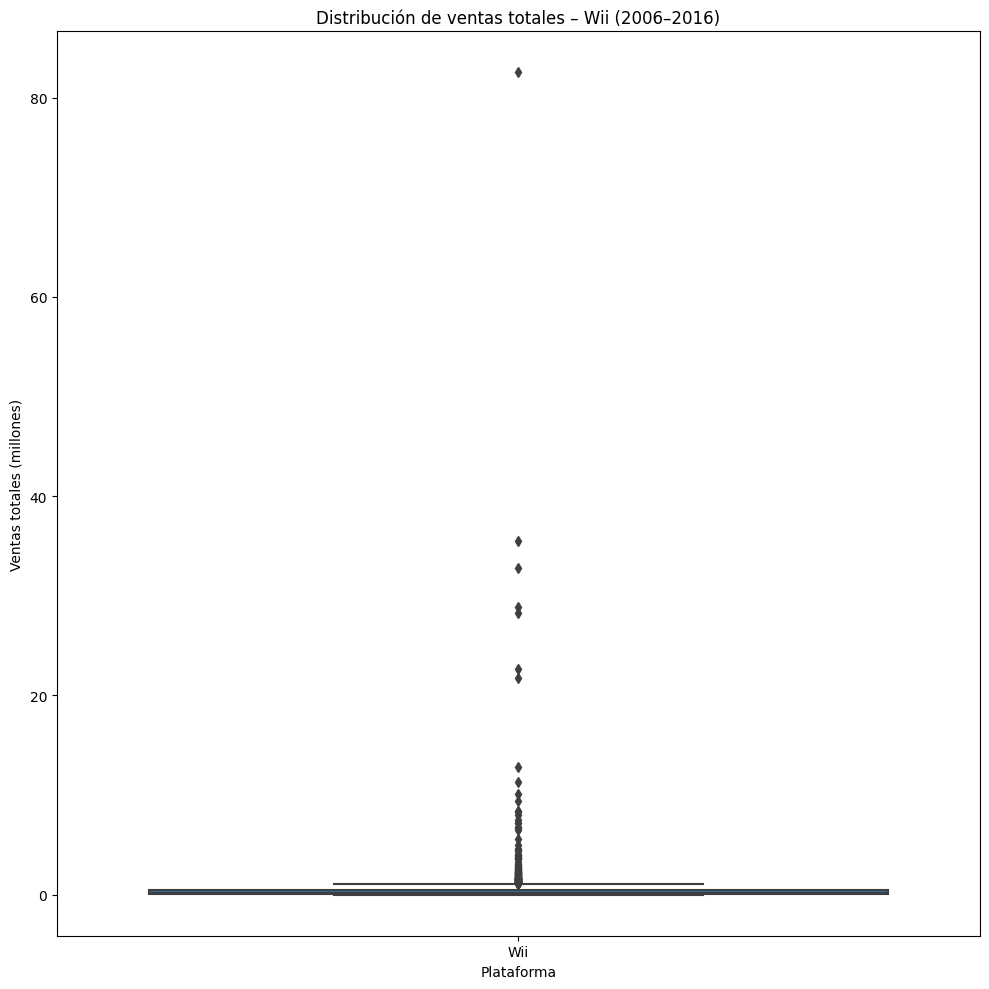

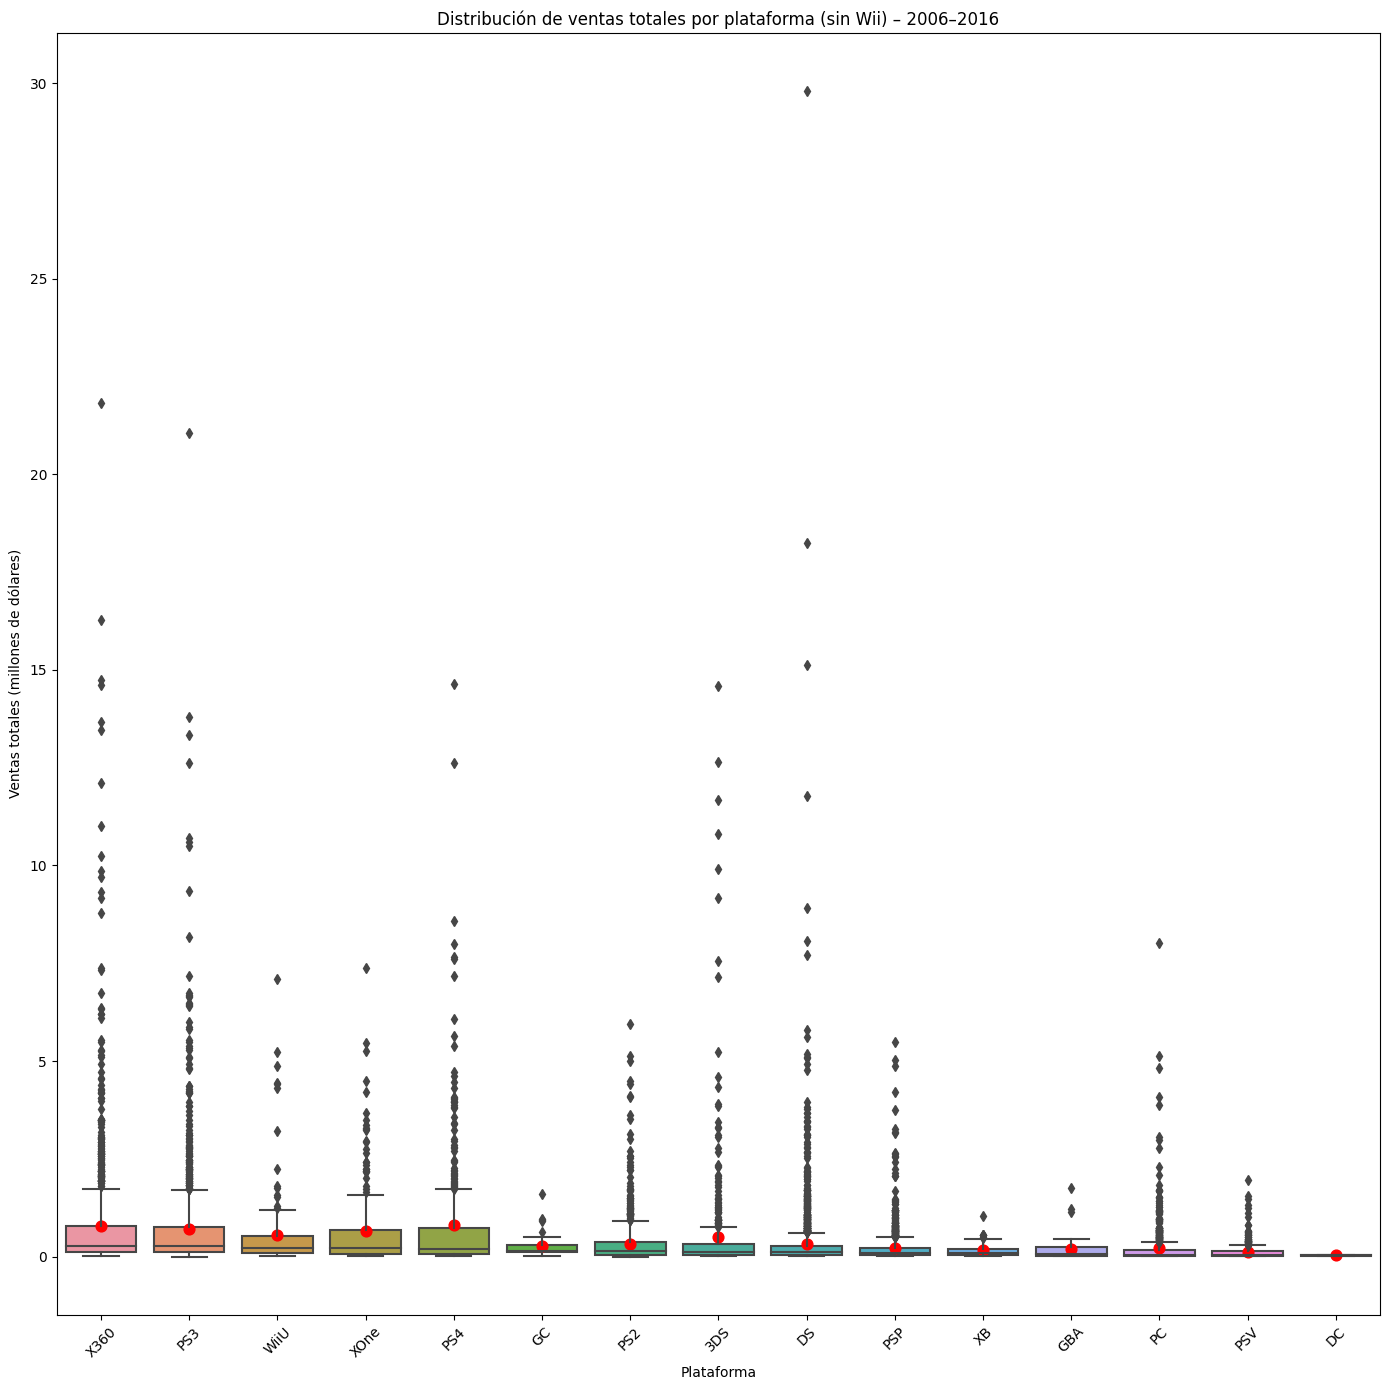

In [14]:
## Diagramas de caja para las ventas globales de todos los juegos, por plataforma.

# 1. Filtrar desde 2006 en adelante
games_2006 = games[games['year_of_release'] >= 2006]

# 2. Separar Wii del resto de plataformas
games_wii = games_2006[games_2006['platform'] == 'Wii']
games_rest = games_2006[games_2006['platform'] != 'Wii']

# 3. Calcular la mediana de ventas por plataforma
median_order_rest = (
    games_rest.groupby('platform')['total_sales']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Boxplots ordenados por mediana
# Gráfico 1: Solo Wii
plt.figure(figsize=(10,10))
sns.boxplot(
    data=games_wii,
    x='platform',
    y='total_sales'
)

plt.title('Distribución de ventas totales – Wii (2006–2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones)')
plt.tight_layout()
plt.show()

# Gráfico 2: Resto de plataformas
plt.figure(figsize=(14,14))
sns.boxplot(
    data=games_rest,
    x='platform',
    y='total_sales',
    order=median_order_rest
)


# Agregar la media al gráfico (en rojo)
means = games_rest.groupby('platform')['total_sales'].mean()

for i, platform in enumerate(median_order_rest):
    plt.scatter(
        i, 
        means[platform], 
        color='red', 
        s=60, 
        label='Media' if i == 0 else ""
    )


plt.title('Distribución de ventas totales por plataforma (sin Wii) – 2006–2016')
plt.xlabel('Plataforma')
plt.ylabel('Ventas totales (millones de dólares)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### ¿Son significativas las diferencias en las ventas?
Las medianas entre las diferentes plataformas son practicamente indiferenciables, así como también sus rangos intercuartílicos. Lo que marca una gran diferencia en las ventas son los valores atípicos de cada plataforma, es decir, juegos que se venden mucho por sobre otros. Destacando en primer lugar un juego en particular de la consola Nintendo Wii, donde tuvo ventas de ~80 milones de dólares. Así también, esta misma plataforma que tiene otros 5 juegos con ventas entre los 20 y 40 millones de dólares. Respecto a otras plataformas como la X360, PS3, PS4, 3DS y DS, también tiene juegos puntuales que hizo que sus ventas sean muy grandes en comparación con sus propias medianas. En conclusión para todas estas plataformas, hay una gran cantidad de juegos que se escapan considerablemente de la mediana y del 50% medio de la muestra.
#### ¿Qué sucede con las ventas promedio en varias plataformas?
Como se puede observar en el gráfico, la media de la mayoría de las plataformas se ubica cerca del cuartil 3 (Q3), donde se ubica el 75% de la distribución de los datos. En las primeras 5 plataformas (X360, PS3, WiiU, XOne y PS4) es bastante similar el promedio de ventas, pero el resto de plataformas tiene una media inferior, incluso, dos a tres veces menor.
#### Otras posibles plataformas rentables:
Además de la PS4 y 3DS, pueden ser potencialmente rentables las plataformas WiiU y XOne que fueron lanzadas el 2012 y 2013, respectivamente. Si bien llevan 3 a 4 años ya en el mercado, aún faltan un par de años para que sigan siendo rentables.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Buen trabajo justificando el período de análisis desde 2006 y usando boxplots para comparar ventas globales por plataforma. También es acertado separar Wii para evitar que sus valores extremos oculten el comportamiento del resto de plataformas.
</div>


### Correlación entre reseñas (usuarios y profesionales) vs. ventas de plataforma (PS4)

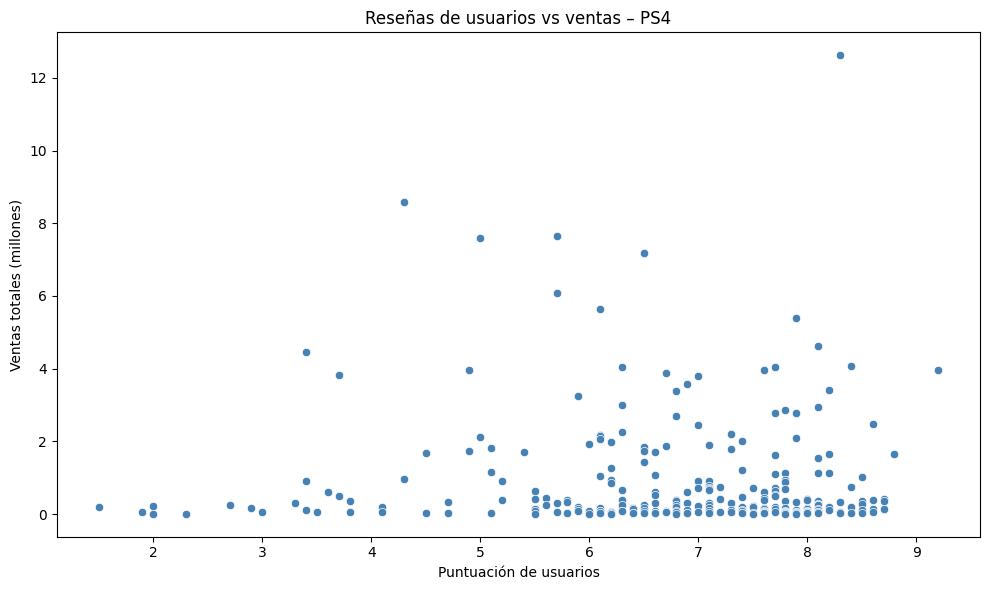

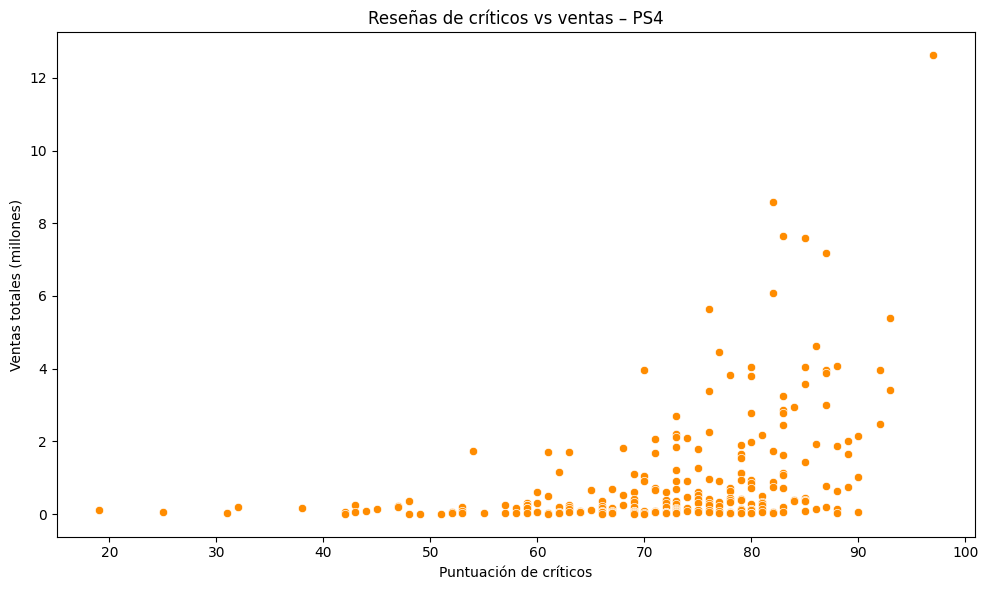

Correlación usuarios vs ventas (PS4): -0.031957110204556376
Correlación críticos vs ventas (PS4): 0.40656790206178095


In [15]:
## Creación de dos gráficos de dispersión para correlacionar reseñas vs. ventas
# 1. Gráfico de reseñas de usuarios vs. ventas de juegos de PS4
games_ps4 = games[games['platform'] == 'PS4']

ps4_user = games_ps4.dropna(subset=['user_score', 'total_sales'])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ps4_user,
    x='user_score',
    y='total_sales',
    color='steelblue'
)

plt.title('Reseñas de usuarios vs ventas – PS4')
plt.xlabel('Puntuación de usuarios')
plt.ylabel('Ventas totales (millones)')
plt.tight_layout()
plt.show()

# 2. Gráfico de reseñas de profesionales vs. ventas de juegos de PS4
ps4_critic = games_ps4.dropna(subset=['critic_score', 'total_sales'])

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=ps4_critic,
    x='critic_score',
    y='total_sales',
    color='darkorange'
)

plt.title('Reseñas de críticos vs ventas – PS4')
plt.xlabel('Puntuación de críticos')
plt.ylabel('Ventas totales (millones)')
plt.tight_layout()
plt.show()

# 3. Correlación entre reseñas de usuarios y ventas de juegos de PS4
corr_user = ps4_user['user_score'].corr(ps4_user['total_sales'])
print('Correlación usuarios vs ventas (PS4):', corr_user)

# 4. Correlación entre reseñas de profesionales y ventas de juegos de PS4
corr_critic = ps4_critic['critic_score'].corr(ps4_critic['total_sales'])
print('Correlación críticos vs ventas (PS4):', corr_critic)


#### Correlación entre reseñas y ventas de PS4:


La correlación entre las reseñas de usuarios con las ventas de juegos del PS4 es negativa y muy baja, es decir, básicamente inexistente. En cuanto a la correlación de los críticos vs. las ventas, es positiva pero sigue estando lejos de 1 (que vendría siendo una fuerte correlación positiva), siendo de 0.4, que indica una leve relación, pero no significativa. Esto también se aprecia en los gráficos donde no se observa una línea de tendencia entre ambas variables.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
El análisis de correlación para PS4 está bien planteado: usas gráficos de dispersión, calculas correlaciones para <code>user_score</code> y <code>critic_score</code>, y explicas correctamente que las relaciones encontradas son débiles o moderadas, no determinantes.
</div>


### Comparación de ventas de estos mismos juegos, pero en otras plataformas

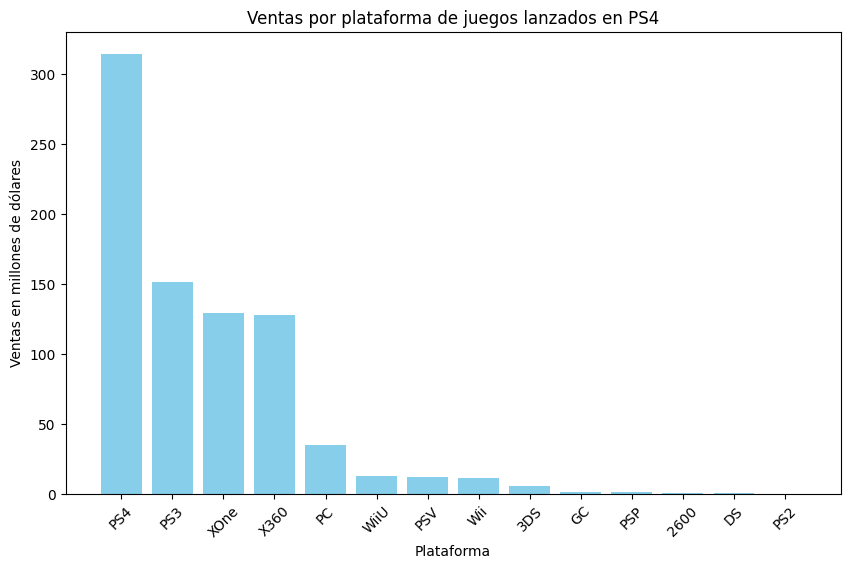

In [16]:
# 1. Obtener una lista solo con los juegos vendidos por la PS4
ps4_games = games[games['platform'] == 'PS4']['name'].unique()

# 2. Filtrar 'games' por los juegos previamente seleccionados
filtered_games = games[games['name'].isin(ps4_games)]

# 3. Agrupar ventas por plataforma
platform_sales = (
    filtered_games.groupby('platform')['total_sales']
    .sum()
    .reset_index()
    .sort_values(by='total_sales', ascending=False)
)

# 4. Graficar ventas en mill. de dólares vs. plataformas
plt.figure(figsize=(10,6))
plt.bar(platform_sales['platform'], platform_sales['total_sales'], color='skyblue')
plt.xlabel('Plataforma')
plt.ylabel('Ventas en millones de dólares')
plt.title('Ventas por plataforma de juegos lanzados en PS4')
plt.xticks(rotation=45)
plt.show()

#### Ventas de los mismos juegos de la PS4, pero en otras plataformas:
Se observa que la plataforma PS4 vende el doble que las siguientes tres plataformas que le continúan en ventas, llegando a vender hasta 300 millones de dólares, en cambio, otras plataformas de alto alcance como la PS3, XOne y X360 venden un poco menos de la misma para los mismos juegos (~150 mill. de dólares). También es interesante ver que para estos juegos, vende más el PC que la WiiU, Wii y 3DS, pero sigue siendo muy por debajo de lo que venden las otras plataformas antes mencionadas.

### Distribución de ventas (en millones de dólares) por género

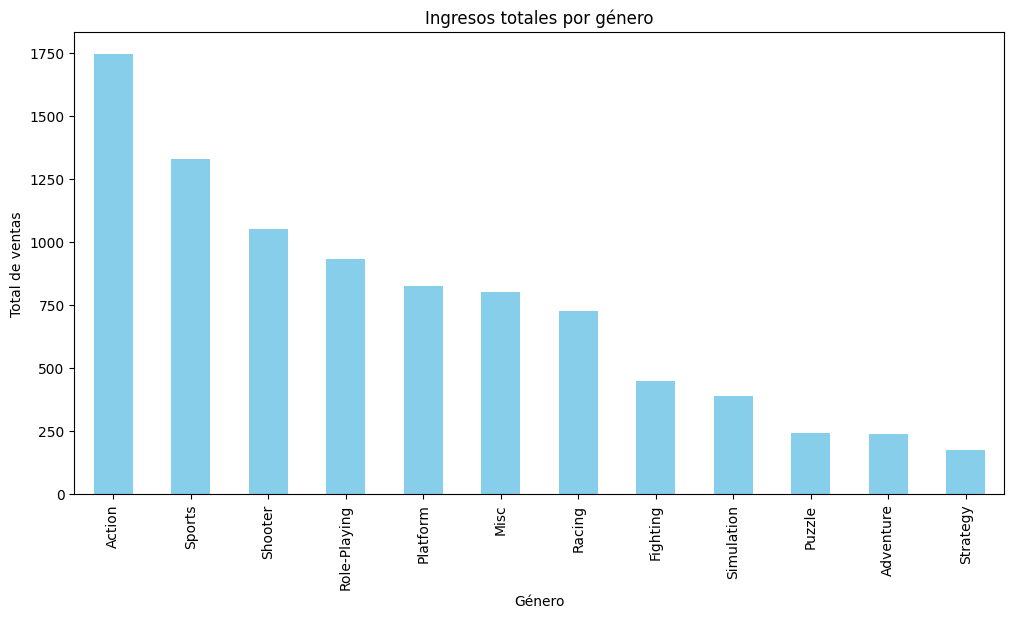

In [17]:
# Total de ingresos por ventas por género
ingresos_por_genero = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)

# Crear gráfico
plt.figure(figsize=(12,6))
ingresos_por_genero.plot(kind='bar', color='skyblue')

# Títulos y etiquetas
plt.title('Ingresos totales por género')
plt.xlabel('Género')
plt.ylabel('Total de ventas')

# Mostrar gráfico
plt.show()


#### ¿Cuáles son los géneros más rentables?
Para definir si un género es más rentable que otro habría que considerar no solo las ventas que han generado estos géneros sino también la inversión. Pero, asumiendo que la inversión va a ser mucho menor que la ganancia posterior, se podría decir que los juegos de acción, deportes y shooters son muy rentables vendiendo por sobre los 1000 millones de dólares en sus totales históricos (hasta 2016 al menos).

#### ¿Cuáles son los géneros con ventas más bajas y altas? ¿Se asocian a algo?
Los géneros con ventas más altas son los juegos de acción, deportes, de disparos, de role-playing y de plataforma. Los que menos venden son los de tipo puzzle, aventura y estrategia.
Podría ser que los juegos donde hay que actuar más rápido se venden más y los juegos donde hay que aplicar más lógica que rapidez se venden menos, pero también puede tener que ver con la publicidad que ciertas plataformas invierten en juegos de distinto género.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
La revisión por género cumple con el objetivo: identificas los géneros con mayores ventas globales y haces una interpretación razonable sobre Action, Sports y Shooter. Bien por aclarar que “rentabilidad” estrictamente requeriría información de costos, no solo ventas.
</div>


## Creación de un perfil de usuario para cada región

### Perfil de usuario: Norteamérica

Top 5 plataformas en NA:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 géneros en NA:
genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64
Correlación Spearman: 0.03761619186644182
p-value: 0.0003139554348672488


/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


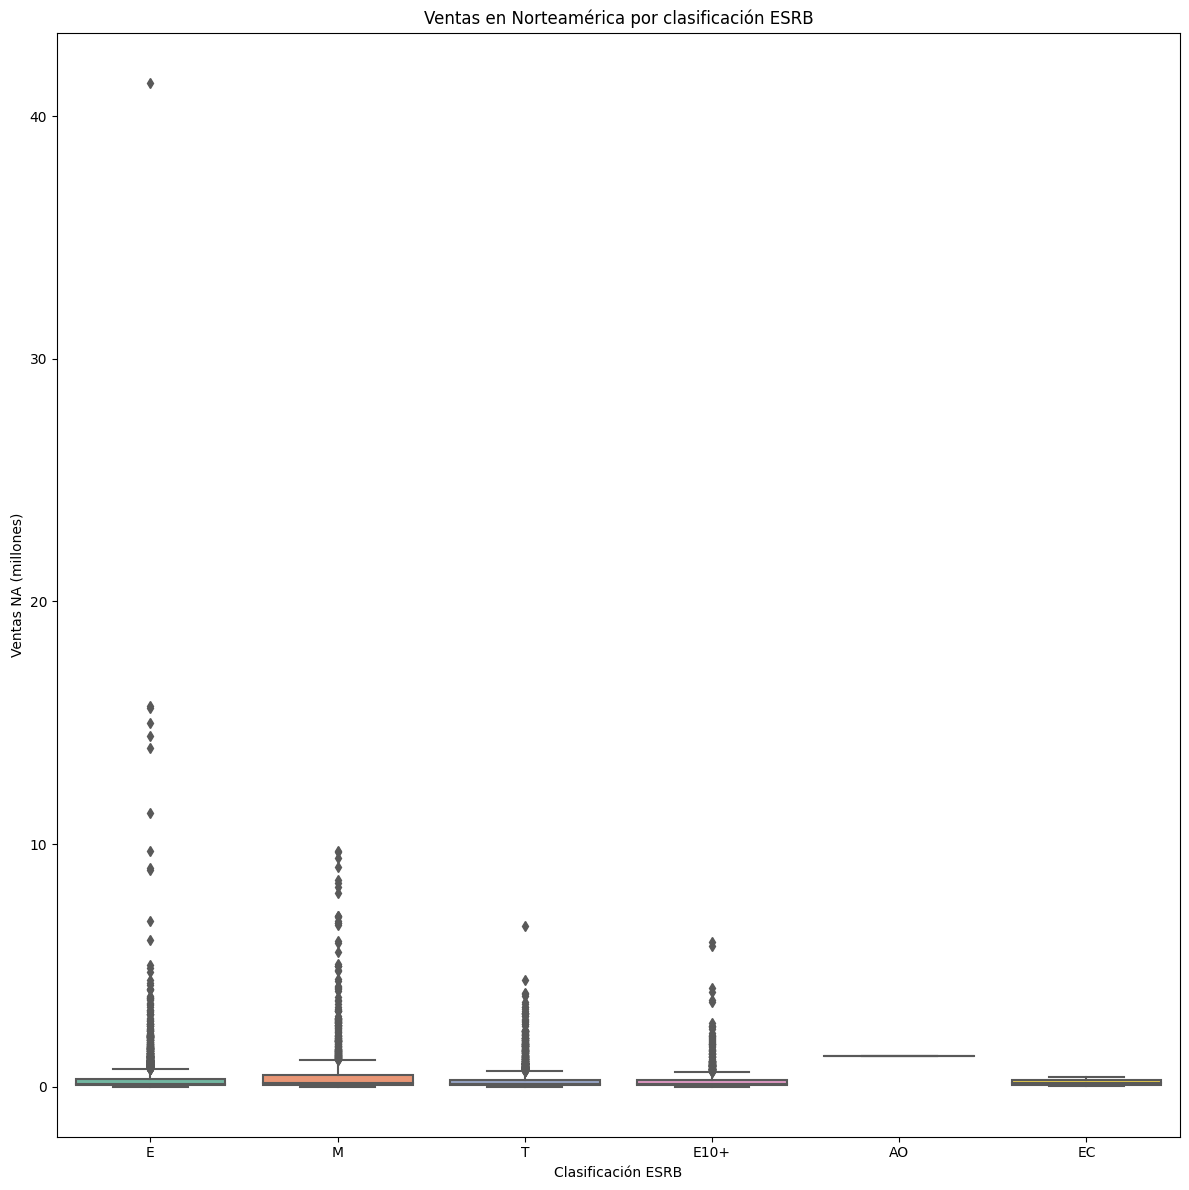

In [18]:
# 1. Filtrar por norteamérica (en este caso se usa la columna na_sales para filtrar)
games_na = games[games['na_sales'] > 0]

# 2. Definir las 5 plataformas principales

top_platforms_na = (
    games_na.groupby('platform')['na_sales']
            .sum()
            .sort_values(ascending=False)
            .head(5)
)


# 3. Definir los 5 géneros principales

top_genres_na = (
    games_na.groupby('genre')['na_sales']
            .sum()
            .sort_values(ascending=False)
            .head(5)
)

print("Top 5 plataformas en NA:")
print(top_platforms_na)

print("\nTop 5 géneros en NA:")
print(top_genres_na)

# 4. Correlacionar clasificaciones ESRB vs. ventas regionales (en este caso NA)
# 4.1 Cambiar los valores categóricos a numéricos para poder correlacionar
rating_map = {
    'EC': 0,
    'E': 1,
    'E10+': 2,
    'T': 3,
    'M': 4,
    'AO': 5
}


games_na.loc[:, 'rating_num'] = games_na['rating'].map(rating_map)

# 4.2 Limpiar valores ausentes
games_na_clean = games_na.dropna(subset=['rating_num', 'na_sales'])

# 4.3 Aplicar correlación de Spearman que es mejor para variables categóricas
spearman_corr, spearman_p = spearmanr(games_na_clean['rating_num'], 
                                      games_na_clean['na_sales'])

print("Correlación Spearman:", spearman_corr)
print("p-value:", spearman_p)

# 4.4 Gráfica
games_na = games_na.dropna(subset=['rating'])

plt.figure(figsize=(12,12))

sns.boxplot(
    data=games_na,
    x='rating',
    y='na_sales',
    palette='Set2'
)

plt.title('Ventas en Norteamérica por clasificación ESRB')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas NA (millones)')
plt.tight_layout()
plt.show()

### Perfil de usuario: Europa

Top 5 plataformas en EU:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 géneros en EU:
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64
Correlación Spearman: 0.07452426162107922
p-value: 4.240947395482434e-11


/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


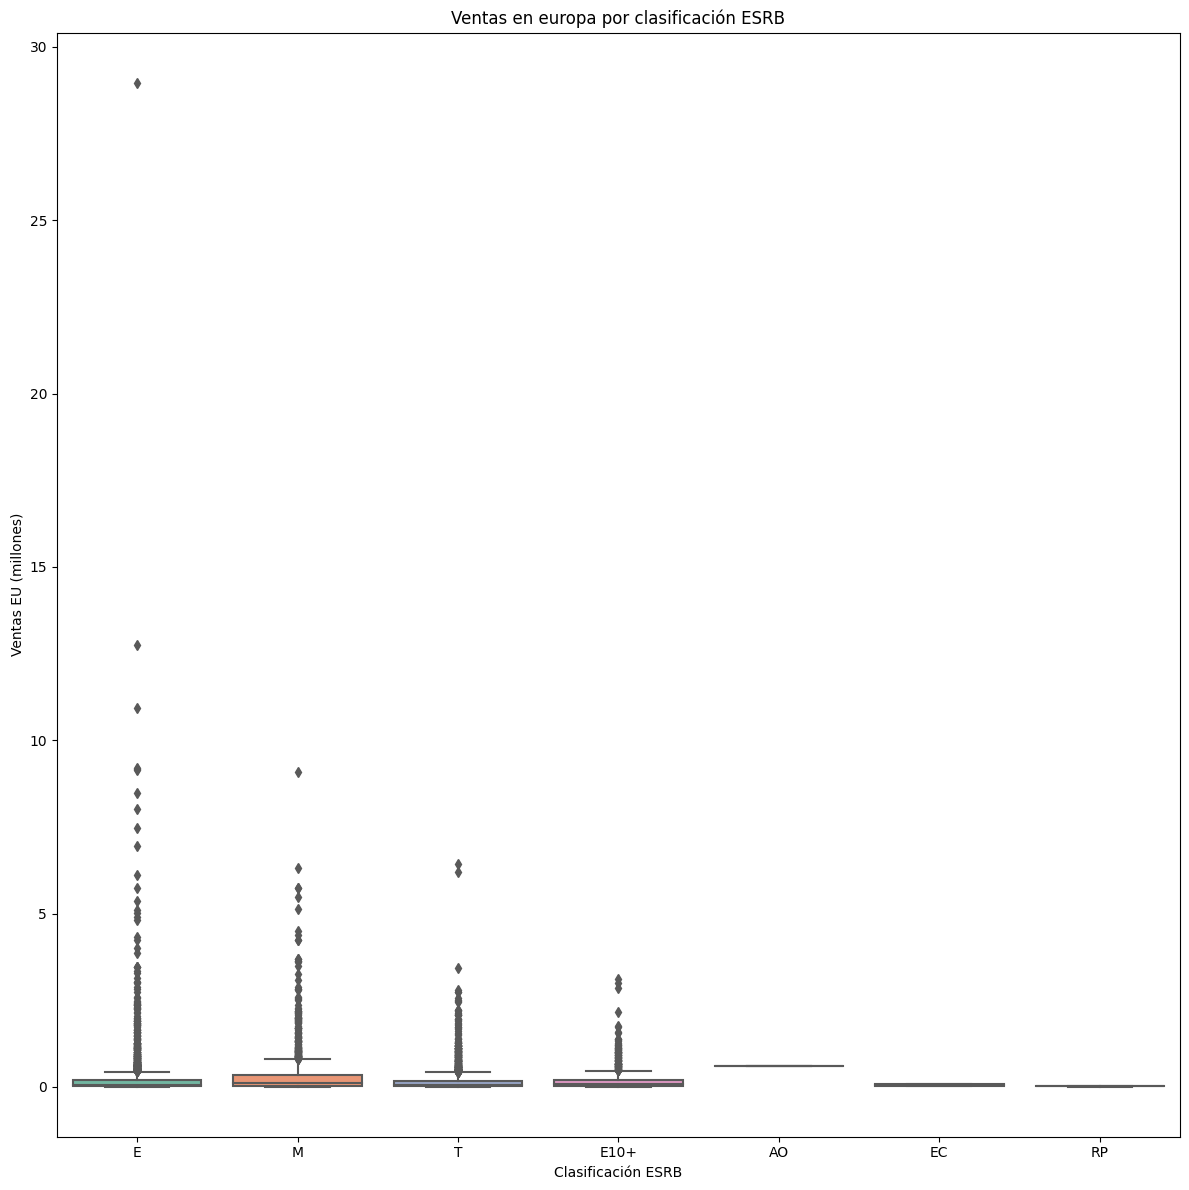

In [19]:
# 1. Filtrar por Europa (en este caso se usa la columna eu_sales para filtrar)
games_eu = games[games['eu_sales'] > 0]

# 2. Definir las 5 plataformas principales

top_platforms_eu = (
    games_eu.groupby('platform')['eu_sales']
            .sum()
            .sort_values(ascending=False)
            .head(5)
)


# 3. Definir los 5 géneros principales

top_genres_eu = (
    games_eu.groupby('genre')['eu_sales']
            .sum()
            .sort_values(ascending=False)
            .head(5)
)

print("Top 5 plataformas en EU:")
print(top_platforms_eu)

print("\nTop 5 géneros en EU:")
print(top_genres_eu)


# 4. Correlacionar clasificaciones ESRB vs. ventas regionales
# 4.1 Reemplazar los valores categóricos a numéricos
games_eu.loc[:, 'rating_num'] = games_eu['rating'].map(rating_map)

# 4.2 Limpiar valores ausentes
games_eu_clean = games_eu.dropna(subset=['rating_num', 'eu_sales'])

# 4.3 Aplicar correlación de Spearman que es mejor para variables categóricas
spearman_corr, spearman_p = spearmanr(games_eu_clean['rating_num'], 
                                      games_eu_clean['eu_sales'])

print("Correlación Spearman:", spearman_corr)
print("p-value:", spearman_p)

# 4.4 Gráfica con boxplot
games_eu = games_eu.dropna(subset=['rating'])

plt.figure(figsize=(12,12))

sns.boxplot(
    data=games_eu,
    x='rating',
    y='eu_sales',
    palette='Set2'
)

plt.title('Ventas en europa por clasificación ESRB')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas EU (millones)')
plt.tight_layout()
plt.show()

### Perfil de usuario: Japón

Top 5 plataformas en JP:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64

Top 5 géneros en JP:
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64
Correlación Spearman: -0.12498535574106356
p-value: 3.954325951791204e-09


/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1597: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[key] = value
/.venv/lib/python3.9/site-packages/pandas/core/indexing.py:1676: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


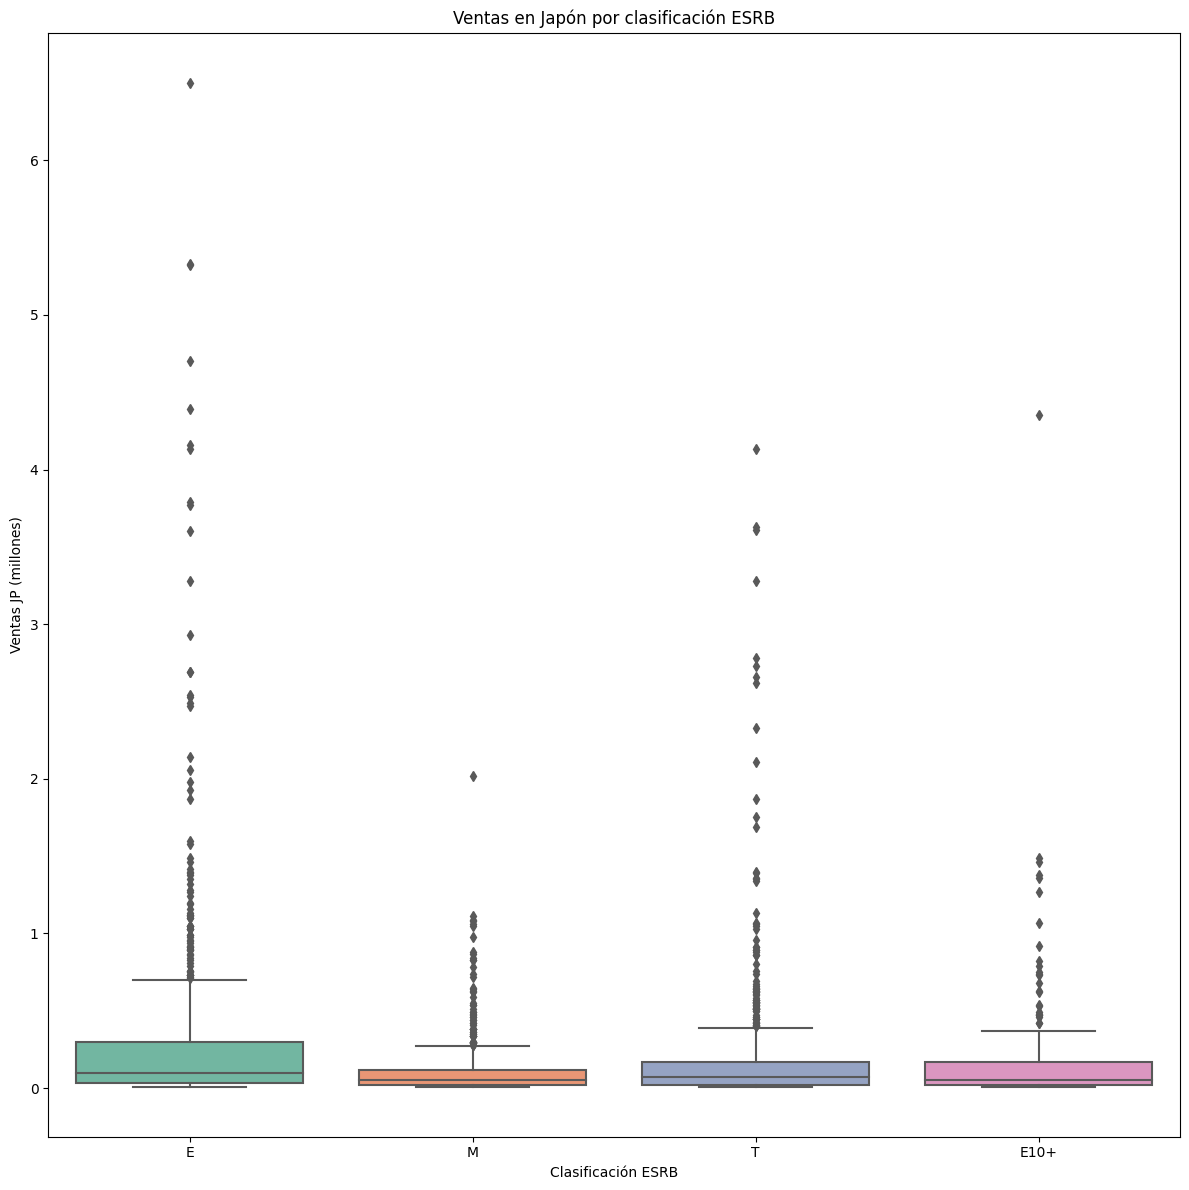

In [20]:
# 1. Filtrar por Japón (en este caso se usa la columna jp_sales para filtrar)
games_jp = games[games['jp_sales'] > 0]

# 2. Definir las 5 plataformas principales
top_platforms_jp = (
    games_jp.groupby('platform')['jp_sales']
            .sum()
            .sort_values(ascending=False)
            .head(5)
)

# 3. Definir los 5 géneros principales
top_genres_jp = (
    games_jp.groupby('genre')['jp_sales']
            .sum()
            .sort_values(ascending=False)
            .head(5)
)

print("Top 5 plataformas en JP:")
print(top_platforms_jp)

print("\nTop 5 géneros en JP:")
print(top_genres_jp)

# 4. Correlacionar clasificaciones ESRB vs. ventas regionales
# 4.1 Reemplazar valores categóricos por numéricos
games_jp.loc[:, 'rating_num'] = games_jp['rating'].map(rating_map)

# 4.2 Limpiar valores ausentes
games_jp_clean = games_jp.dropna(subset=['rating_num', 'jp_sales'])

# 4.3 Aplicar correlación de Spearman que es mejor para variables categóricas
spearman_corr, spearman_p = spearmanr(games_jp_clean['rating_num'], 
                                      games_jp_clean['jp_sales'])

print("Correlación Spearman:", spearman_corr)
print("p-value:", spearman_p)

# 4.4 Gráfica de boxplot
games_jp = games_jp.dropna(subset=['rating'])

plt.figure(figsize=(12,12))

sns.boxplot(
    data=games_jp,
    x='rating',
    y='jp_sales',
    palette='Set2'
)

plt.title('Ventas en Japón por clasificación ESRB')
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas JP (millones)')
plt.tight_layout()
plt.show()

### Diferencia de ventas entre las tres regiones:

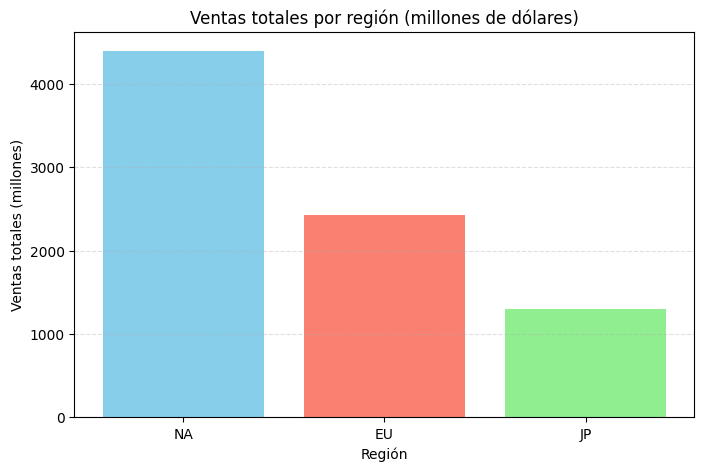

In [21]:
# Gráfico de diferencia de ventas entre las tres regiones:

# Sumar ventas por región
ventas = games[['na_sales', 'eu_sales', 'jp_sales']].sum()

# Crear gráfico
plt.figure(figsize=(8, 5))
plt.bar(['NA', 'EU', 'JP'], ventas,
        color=['skyblue', 'salmon', 'lightgreen'])

plt.title('Ventas totales por región (millones de dólares)')
plt.xlabel('Región')
plt.ylabel('Ventas totales (millones)')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

#### ¿Hay variaciones en las cuotas de mercado entre una región y otra?
Norteamérica es la región que más vende, vendiendo casi el doble que la región de Europa y tres veces lo de Japón. También hay una diferencia importante en las plataformas que venden los juegos. En Norteamérica las plataformas principales que hitóricamente han vendido más son la X360, PS2, Wii, PS3 y DS. En Europa es similar con las plataformas PS2, PS3, X360, Wii y PS. Cambia un poco en Japón, donde las plataformas que más han vendido son la DS, PS, PS2, SNES y 3DS.
#### ¿Cuáles son las diferencias entre los géneros de diferentes regiones?
Tanto para Norteamérica y Europa los tres géneros que más se venden son los de Acción, Deportes y Shooters, luego se diferencian en el cuarto género que en el caso de NA son los juegos de Plataforma y en el caso de Europa son de Carrera. Para el caso de Japón es un poco diferente, donde los primeros tres géneros más vendidos son los de Role-playing, Acción y Deportes y el cuarto es de Plataforma.
#### ¿Afectan diferente las clasificaciones ESRB en las tres regiones?
En cuanto a tipo de ventas, los tipos de juegos que más se venden para las tres regiones son E (cualquiera), M (adultos) , T (adolescentes) y E10+ (cualquiera mayor a 10 años). En particular, para el caso de Norteamérica, sus grandes outliers que generan grandes ventas corresponden a la categoría E con ventas de hasta ~40 mill. de dólares y muchos juegos que venden hasta los 15 mill. de dólares y para la categoría M (segunda categoría con más ventas) llegan las ventas hasta los 10  mill. de dólares. Para el caso de Europa, la distribución es muy similar, solo que con menores ventas. En la categoría E hay ventas de hasta los 28 mill. de dólares y muchas hasta los 13 mill. de dólares y para la categoría M de hasta 10 mill. de dólares. En el caso de Japón, la mayor mediana se ubica en la categoría E (a diferencia de NA y EU que es en M), y sus outliers son levemente diferente, tanto por sus categorías (E, T y E10+) y por la cantidad de ventas (hasta los ~6 mill. de dólares). Puntualmente, Para la categoría E se vende hasta los 6 mill. de dólares pero en su mayoría alcanza ~5 mill. y para la categoría T y E10+ se alcanzan ventas de hasta los 4.5 mill. de dólares.
Ahora en cuanto a si existe una correlación real entre estas categorías y el total de ventas por categoría, en las tres regiones las correlaciones de Spearman indican que no, con valores que van desde los -0.12 a los 0.07 y con valores p muy bajos (no hay significancia estadística para esta prueba).

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
El perfil regional está completo: incluyes top 5 de plataformas y géneros para NA, EU y JP, además del análisis por clasificación ESRB. Como mejora, revisa la frase sobre valores p “muy bajos” y “no significancia”: normalmente, un p-value bajo indica evidencia estadística contra la hipótesis nula. Además, para evitar <code>SettingWithCopyWarning</code>, cuando filtres por región puedes crear copias explícitas con <code>.copy()</code>.
</div>


## Pruebas de hipótesis

### Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [22]:
# 1. Se define como hipótesis nula: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.


# 2. Eliminar valores ausentes y filtrar por plataforma y user_score:
xone_scores = games[games['platform'] == 'XOne']['user_score'].dropna()
pc_scores = games[games['platform'] == 'PC']['user_score'].dropna()

# 3. Calcular varianzas para definir un equal_var False o True:
var_xone = np.var(xone_scores, ddof=1)
var_pc = np.var(pc_scores, ddof=1)

# 4. Obtener medias de XboxOne y PC
xbox_one_mean = xone_scores.mean()
pc_mean = pc_scores.mean()

# 5. Impresión de valores
print("Resultados:")
print(f"XOne - Media: {xbox_one_mean:.2f}, Varianza: {var_xone:.2f}")
print(f"PC   - Media: {pc_mean:.2f}, Varianza: {var_pc:.2f}")

# 6. Obtener valor p y rechazar o aprobar hipótesis nula
alpha = 0.05
results = st.ttest_ind(xone_scores, pc_scores, equal_var=True)
print('valor-p:', results.pvalue)
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")



Resultados:
XOne - Media: 6.52, Varianza: 1.91
PC   - Media: 7.06, Varianza: 2.34
valor-p: 1.3896435533548819e-05
Rechazamos la hipótesis nula


### Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [23]:
## Se define como hipótesis nula: Las calificaciones promedio de los géneros de Acción y Deportes son las mismas.

# 2. Eliminar valores ausentes y filtrar por género y user_score:
action_scores = games[games['genre'] == 'Action']['user_score'].dropna()
sports_scores = games[games['genre'] == 'Sports']['user_score'].dropna()

# 3. Calcular varianzas para definir un equal_var False o True:
var_action = np.var(action_scores, ddof=1)
var_sports = np.var(sports_scores, ddof=1)

# 4. Obtener medias de Acción y Deportes
action_mean = action_scores.mean()
sports_mean = sports_scores.mean()

# 5. Impresión de valores
print("Resultados:")
print(f"Acción - Media: {action_mean:.2f}, Varianza: {var_action:.2f}")
print(f"Sports - Media: {sports_mean:.2f}, Varianza: {var_sports:.2f}")

# 6. Obtener valor p y rechazar o aprobar hipótesis nula
alpha = 0.05
results = st.ttest_ind(action_scores, sports_scores, equal_var=True)
print('valor-p:', results.pvalue)
if results.pvalue < alpha:
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")


Resultados:
Acción - Media: 7.05, Varianza: 2.03
Sports - Media: 6.96, Varianza: 2.60
valor-p: 0.10406951359049141
No podemos rechazar la hipótesis nula


#### ¿Cómo se formuló la hipótesis nula y alternativa?
Se formularon las hipótesis en función de definir si la media de una población es mayor o menor que la media de otra población estadística. En este caso, las poblaciones para la primera hipótesis son clasificaciones de usuarios de la plataforma XOne y clasificaciones de usuarios de la plataforma PC y para la segunda hipótesis la primera población es la clasificación de usuarios del género acción y la otra es del género deportes. Como hipótesis nula se debe asumir que no hay diferencia entre las poblaciones, en este caso, en la media de las poblaciones y la hipótesis alternativa propone lo contrario (si hay diferencias en las poblaciones).
#### ¿Qué criterio se utilizó para probar las hipótesis y por qué?
Con lo anterior como base, se escogió el método scipy.stats.ttest_ind(array1, array2, equal_var) que sirve para pobrar la hipótesis de que las medias de dos poblaciones estadísticas son iguales. Para esto también se tuvo que definir si sus varianzas eran iguales o similares para definir un equal_var = False o True. En ambos casos eran casi iguales así que se escogío un equal_var = True.
#### ¿Qué se determinó con estas pruebas de hipótesis?
Para definir si las clasificaciones promedio de los usuarios para la XOne y PC eran iguales, la prueba de hipótesis arrojó que se rechaza la hipotesis nula, es decir, no son iguales los promedios. Un promedio es de 6.5 y el otro es de 7 para XOne y PC, respectivamente. En cambio, para la clasificación promedio de los usuarios para los géneros de Acción y Deportes no se pudo rechazar la hipótesis nula, es decir, infiere que los promedios son estadísticamente similares o visto de otra forma, no son lo suficientemente diferentes. Esto se observa también en el resultado de las medias que dan 7.05 y 6.96 para acción y deportes, respectivamente.


<div class="alert alert-block alert-danger">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
<b>A resolver 🔴</b><br>
En las pruebas de hipótesis estás usando <code>alpha = 0.5</code>, pero este valor no es adecuado para este tipo de análisis. Recuerda que <code>alpha</code> representa el nivel de significancia: es decir, el margen de error que aceptamos al decidir si rechazamos o no la hipótesis nula. Usar <code>0.5</code> equivale a aceptar un 50% de probabilidad de cometer un error, lo cual es demasiado alto y puede llevar a conclusiones poco confiables. Para este proyecto debes usar el valor estándar <code>alpha = 0.05</code>, que corresponde a un nivel de significancia del 5%. Por favor, corrige este valor y vuelve a interpretar los resultados de ambas pruebas, especialmente la comparación entre Action y Sports.
</div>


<div class="alert alert-block alert-success">
<b>Comentario de la revisora. (Iteración 2)</b> <a class="tocSkip"></a><br>
<b>Corrección verificada ✅</b><br>
Buen ajuste, Catalina. Cambiaste el nivel de significancia a <code>alpha = 0.05</code> en ambas pruebas de hipótesis y reinterpretaste correctamente los resultados. En particular, para Action vs Sports, el <code>p-value</code> queda por encima de 0.05, por lo que la decisión correcta es no rechazar la hipótesis nula.
</div>

# Paso 5. Conclusiones

##### A partir de esta base de datos se pueden observar varios patrones de venta por plataforma y por años de lanzamiento y de preferencias de usuarios en plataformas y géneros. 
##### En general, las plataformas de las marcas Sony y Nintendo han sido muy exitosas, por ejemplo, las distintas versiones de PlayStation, Wii y DS. También empezó a destacar de forma un poco más tardía las plataformas de Microsoft como X360 y XOne. Por otro lado, destaca también el PC, que si bien no alcanza la cantidad de ventas que las otras plataformas, ha sido constante desde los años 90 (según datos de esta base de datos).
##### También es importante notar que, tanto en la cantidad de juegos vendidos como en la cantidad de ventas en millones de dólares, se siguen patrones donde se suele observar una distribución normal a asimétrica negativa. Parten vendiendo poco o medianamente poco, luego alcanzan su peak y finalmente de a poco se dejan de vender. Este patrón se puede explicar ya que cada ciertos años (entre 6 a 11 años), van lanzando nuevas plataformas más actualizadas que reemplazan completamente la anterior. Ejemplo de esto son las PlayStation (PS, PS2, PS3 y PS4), las DS (DS y 3DS), las XBox (XB, X360, XOne) y las Wii (Wii y WiiU).
##### Los patrones entre las diferentes regiones es bastante similar, tanto en elecciones de plataformas como en géneros elegidos, solo difiere un poco Japón en gustos de género, pero sigue siendo muy similar a Europa y Norteamérica.
##### Llama la atención que las puntuaciones de usuarios y críticos hacia los juegos no se relacionan mucho según estos datos. La razón para esto puede ser que los juegos se venden masivamente apenas son lanzados por un buen marketing (por ejemplo, videos promocionales) y es el periodo de mayor venta, luego las ventas de estos mismos decaen, por tanto, la opinión de críticos y usuarios ya no importaría tanto.
##### Respecto a estos usuarios, analizando las pruebas de hipótesis, también se puede apuntar que estos generan opiniones más opuestas respecto a cuál plataforma prefieren, más que a qué género es mejor o no.
##### Las clasificaciones ESRB indican que los videojuegos aptos para adultos y adolescentes son los que más venden, que indican que gente más adulta es la que más juega en estas plataformas y que puede estar ligado también a los géneros asociados a gente mayor como son los juegos de acción y shooters.

<div class="alert alert-block alert-warning">
<b>Comentario de la revisora. (Iteración 1)</b> <a class="tocSkip"></a><br>
Las conclusiones recogen bien varios hallazgos del análisis, pero deben ajustarse después de corregir <code>alpha</code>. También evita frases causales como “las puntuaciones no influyen en cómo se venden”; con correlaciones débiles podemos decir que “no se observa una relación fuerte en estos datos”, pero no afirmar influencia o ausencia de influencia de forma causal.
</div>
